### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue


### TODOs (Suryansh)
2. Stop word analysis for GT and generated

In [11]:
import pandas as pd
import os
from tqdm.auto import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer
from jiwer import wer
import jiwer

# Define a robust transformation pipeline
# This applies data cleaning steps in order, from top to bottom
JIWER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(),                # Convert all text to lowercase
    jiwer.RemovePunctuation(),          # Strip characters like commas, periods, question marks
    jiwer.RemoveMultipleSpaces(),       # Turn multi-spaces into a single space
    jiwer.Strip(),                      # Clean up leading/trailing whitespaces
    jiwer.ReduceToListOfListOfWords()   # Format text tokens perfectly for jiwer's internal engine
])


pd.set_option('display.max_colwidth', None)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    # use_stemmer=True,
    use_stemmer=False
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

def load_df_from_path(AMI_PATH):
    meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", f"beam_results.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
    
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
                line[f"meeting_name"] = meeting_path.split("/")[-1]
                
    df = pd.DataFrame(lines)
    return df
    
AMI_TRAIN_PATH = '/group/jrwhitehill/amicorpus/train'
AMI_VAL_PATH = '/group/jrwhitehill/amicorpus/validation'

df = load_df_from_path(AMI_TRAIN_PATH)
df_val = load_df_from_path(AMI_VAL_PATH)

  0%|          | 0/136 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

In [13]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,meeting_name,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,beam_4_text,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob
0,Hello.,Hello,-0.499981,-16.62500,TS3006c,Hello.,-0.166628,-10.25000,Hello.,-0.166628,-10.2500,Hello.,-0.166628,-10.2500,Hello!,-0.749961,-9.25000
1,..,I need to go there.,-0.825584,-8.00000,TS3006c,I think we are going to need to go.,-1.653785,-5.71875,But I'm gonna throw the ball away.,-1.753428,-5.8750,the,-64.277092,-25.6250,I'm gonna get back to the hospital.,-0.878668,-6.37500
2,"Yes, I made it.","Yes, I made it.",-0.060835,-5.09375,TS3006c,"Yes, I made it.",-0.060835,-5.09375,Yes I made it,-0.627244,-7.4375,"Yes, I made it",-0.239422,-5.6875,"Yes, I made it.",-0.060835,-5.09375


In [14]:
import re
import string

def normalize_text(text: str) -> str:
    """Mirrors the jiwer text normalization pipeline, except for last stage"""
    if not text:
        return ""
    
    # 1. jiwer.ToLowerCase()
    text = text.lower()
    
    # 2. jiwer.RemovePunctuation()
    # Removes standard punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. jiwer.RemoveMultipleSpaces()
    text = re.sub(r'\s+', ' ', text)
    
    # 4. jiwer.Strip()
    text = text.strip()
    
    return text

In [15]:
def process_columns(df):
    llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
    asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]
    
    llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
    asr_logprobs = torch.tensor(df[asr_logprob_columns].values)
    
    # # ALL BEAMS
    # scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
    # highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
    # highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)

    # JUST BEAM 1
    scores = llm_logprobs
    highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]


    # AGGREGATED STATS
    df['max_llmlogprobs'] = torch.max(llm_logprobs, dim=1).values.numpy()
    df['min_llmlogprobs'] = torch.min(llm_logprobs, dim=1).values.numpy()
    df['spread_llmlogprobs'] = df['max_llmlogprobs'] - df['min_llmlogprobs']

    df['max_asrlogprobs'] = torch.max(asr_logprobs, dim=1).values.numpy()
    df['min_asrlogprobs'] = torch.min(asr_logprobs, dim=1).values.numpy()
    df['spread_asrlogprobs'] = df['max_asrlogprobs'] - df['min_asrlogprobs']

    df['highest_score'] = highest_scores.numpy()
    
    df['text'] = df['beam_1_text']
    df['num_tokens_text'] = df['beam_1_text'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    df['num_tokens_gt'] = df['gt'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    
    
    df["rougeL"] = [
        rouge_l(normalize_text(pred), normalize_text(ref)).fmeasure
        for pred, ref in zip(df["text"], df["gt"])
    ]
    df["wer"] = [
        min(1.0, wer(reference = ref, hypothesis = pred, reference_transform = JIWER_TRANSFORM, hypothesis_transform = JIWER_TRANSFORM))
        for pred, ref in zip(df["text"], df["gt"])
    ]

process_columns(df)
process_columns(df_val)

In [18]:
df.head(5)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,meeting_name,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,...,spread_llmlogprobs,max_asrlogprobs,min_asrlogprobs,spread_asrlogprobs,highest_score,text,num_tokens_text,num_tokens_gt,rougeL,wer
0,Hello.,Hello,-0.499981,-16.62500,TS3006c,Hello.,-0.166628,-10.25000,Hello.,-0.166628,...,7.37500,-0.166628,-0.749961,0.583333,-16.62500,Hello,2,3,1.000000,0.0
1,..,I need to go there.,-0.825584,-8.00000,TS3006c,I think we are going to need to go.,-1.653785,-5.71875,But I'm gonna throw the ball away.,-1.753428,...,19.90625,-0.825584,-64.277092,63.451508,-8.00000,I need to go there.,7,2,0.000000,1.0
2,"Yes, I made it.","Yes, I made it.",-0.060835,-5.09375,TS3006c,"Yes, I made it.",-0.060835,-5.09375,Yes I made it,-0.627244,...,2.34375,-0.060835,-0.627244,0.566409,-5.09375,"Yes, I made it.",7,7,1.000000,0.0
3,English from now on.,English from now on.,-0.135894,-7.75000,TS3006c,English from now on,-0.304503,-9.25000,English from now on.,-0.135894,...,2.68750,-0.135894,-0.427362,0.291468,-7.75000,English from now on.,6,6,1.000000,0.0
4,. Just kidding.,Drawing or just testing. And we're going to bring that out of all the stress. Just kidding.,-0.698395,-5.03125,TS3006c,"Drawing or just testing? Yeah. We're going to bring you some more. That's all the stress. No. Just kidding. Oh, English.",-0.311134,-4.56250,"Drawing or just testing? Yeah, we're going to go in there. That's all the stress. Just kidding. I don't know.",-0.453075,...,1.09375,-0.311134,-0.725123,0.413989,-5.03125,Drawing or just testing. And we're going to bring that out of all the stress. Just kidding.,22,5,0.210526,1.0


# Stop Word Removal Analysis

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Download standard NLTK stopwords if you haven't already
nltk.download('stopwords', quiet=True)

# 1. Define your complete set of stop words
standard_stops = set(stopwords.words('english'))

# Add ASR-specific conversational fillers (no punctuation, all lowercase)
asr_fillers = {
    "yeah", "alright", "good", "mmhmm", "mm", "hmm", 
    "uh", "um", "ah", "okay", "ok", "oh"
}
all_stop_words = standard_stops.union(asr_fillers)

def contains_meaningful_text(text: str) -> bool:
    """
    Returns True if the text contains non-stop words after cleaning.
    """
    if not isinstance(text, str) or not text.strip():
        return False
        
    # Lowercase the text
    text = text.lower()
    
    # Remove punctuation. 
    # Note: "Mm-hmm" becomes "mmhmm", which is why "mmhmm" is in our custom list above.
    text = re.sub(r'[^\w\s]', '', text)
    
    # Split into words and check against stop words
    words = text.split()
    meaningful_words = [w for w in words if w not in all_stop_words]
    
    # If the list is not empty, there is meaningful text left
    return len(meaningful_words) > 0

# --- Example Usage ---

# Sample DataFrame based on your description
data = {
    'generated text': ["Yeah yeah yeah", "Hello world", "Alright, good", "The model works"],
    'ground truth text': ["yeah", "hi world", "mm-hmm", "model works fine"],
    'ROUGE-L': [0.5, 0.8, 0.0, 0.9],
    'WER': [0.2, 0.3, 1.0, 0.1]
}
test_df = pd.DataFrame(data)

# 2. Create boolean masks for both text columns
mask_gen = test_df['generated text'].apply(contains_meaningful_text)
mask_gt = test_df['ground truth text'].apply(contains_meaningful_text)

# 3. Filter the DataFrame to keep rows where BOTH texts are meaningful
# (If you want to drop rows where AT LEAST ONE is empty, use the `&` operator)
df_filtered = test_df[mask_gen & mask_gt].copy()

print("Original DataFrame:")
print(test_df)
print("\nFiltered DataFrame:")
print(df_filtered)

# whisper text len vs. ground truth text len

In [20]:
import matplotlib.pyplot as plt

def corr_analysis(df, x='highest_score', y='rougeL'):
    df.plot.scatter(x=x, y=y)
    
    # Display the plot
    plt.show()
    
    from scipy.stats import pearsonr
    
    result = pearsonr(df[x], df[y])
    
    print(f"Pearson r: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")

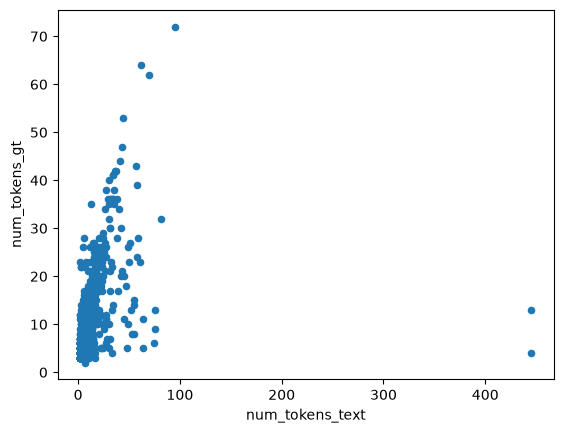

Pearson r: 0.3603
P-value: 0.0000


In [21]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

In [22]:
df = df[df['num_tokens_text'] < 400]
df_val = df_val[df_val['num_tokens_text'] < 400]

short_idx = df['num_tokens_text'] <= 5

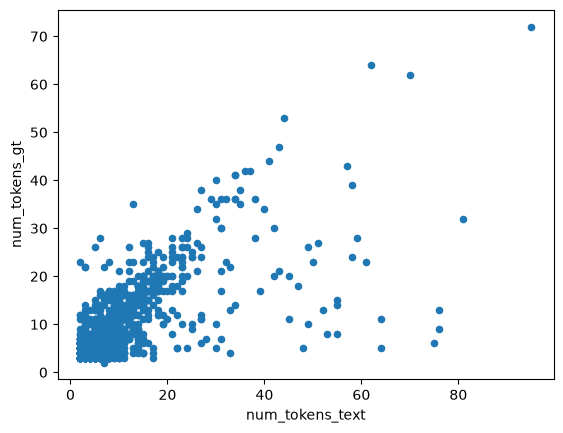

Pearson r: 0.7068
P-value: 0.0000


In [23]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

<Axes: >

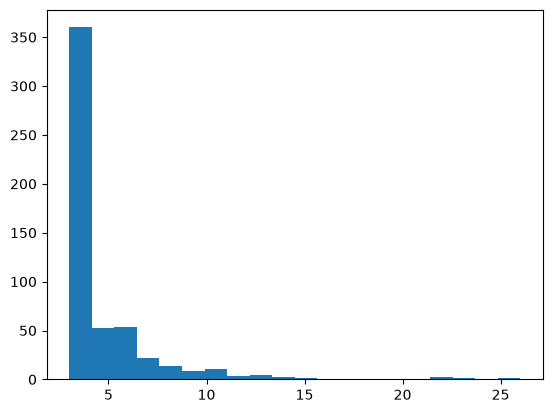

In [24]:
df[short_idx]['num_tokens_gt'].hist(bins=20, grid=False)

In [25]:
# Number of short sequences
sum(short_idx)

537

In [26]:
# Get the number of times GT sequences were longer than generated
sum((df['num_tokens_gt'] > df['num_tokens_text']))

628

In [27]:
# Num of times GT sequences are longer than generated short seqs
sum((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))

369

In [28]:
# % of GT seqs longer than generated short seqs 
len(df[((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))])/len(df[short_idx])

0.6871508379888268

In [29]:
# % of when long seqs had short transcriptions (mostly mistranscriptions)
len(df[((df['num_tokens_gt'] > 5) & (short_idx))])/len(df[short_idx])

0.2309124767225326

In [30]:
# Sample 10 generated short seqs and their equivalent GT
df[short_idx][['text','gt']].sample(10)

,text,gt
196,you,Yeah.
391,you,Mm-hmm.
928,you,Excuse me?
1076,"Well,",Well.
914,Thank you.,Yeah.
22,and for yeah.,This?
509,All right.,Yeah that's good idea.
892,Thank you.,Uh sorry.
872,Yeah.,Yeah.
337,you,Ah.


# errors analysis

In [31]:
df['wer'].describe()

count    1135.000000
mean        0.754742
std         0.336952
min         0.000000
25%         0.500000
50%         1.000000
75%         1.000000
max         1.000000
Name: wer, dtype: float64

In [32]:
df[['text','gt','wer','rougeL']].sample(5)

,text,gt,wer,rougeL
500,you,Yeah.,1.000000,0.000000
102,you,No.,1.000000,0.000000
994,you,Alright.,1.000000,0.000000
630,"or blue and then I do it. Yeah, dark blue and then should use. Then very bright yellow and orange green apple stuff like that. It's very bright tones.","Or and then Oh yeah yeah, dark blue and then and then very bright, uh a yellow banana, an orange, uh a green apple, stuff like that, with very uh bright tones I guess.",0.470588,0.666667
293,Chip? Yeah.,Yeah.,1.000000,0.666667


In [33]:
# Define 0.5 as threshold, this is finding % of what transcriptions were wrong based on ROUGE L
sum(df['rougeL'] < 0.5)/len(df)

0.6458149779735682

In [34]:
# Define 0.5 as threshold, this is finding % of what transcriptions were wrong based on WER
sum(df['wer'] > 0.5)/len(df)

0.7215859030837004

In [38]:
# Recaluculate short indices
short_idx = df['num_tokens_text'] <= 5

In [39]:
# Get indices of mistranscribed seqs based on ROUGE L and WER
errors_rougeL_idx = df['rougeL'] < 0.5
errors_wer_idx = df['wer'] > 0.5

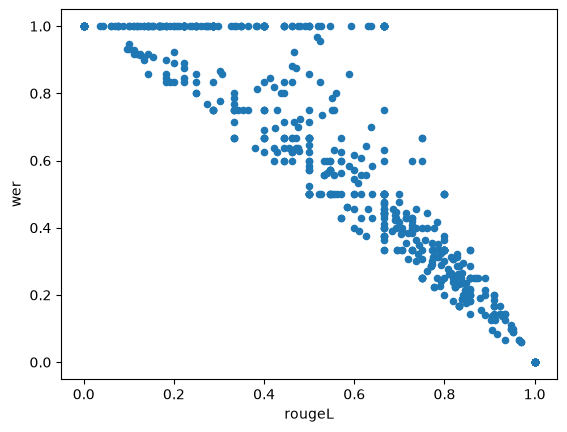

Pearson r: -0.9324
P-value: 0.0000


In [40]:
corr_analysis(df,'rougeL','wer')

<Axes: >

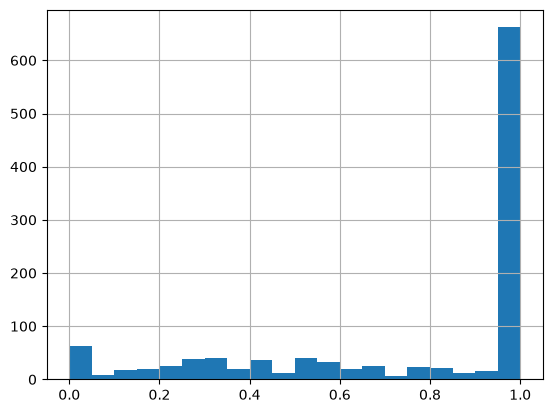

In [41]:
# Generate hist distr of WER
df['wer'].hist(bins=20)

In [42]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
298,That was a lot of fun.,Okay.,0.000000,1.0000
164,Thanks.,Yeah.,0.000000,1.0000
325,Hello.,No.,0.000000,1.0000
921,you,Yeah.,0.000000,1.0000
477,Thank you.,Oh.,0.000000,1.0000
682,"I think it's a bit too much. Yeah, an orange. All right. Well, this is more like purple I guess, but yeah, it should be more real dark blue. So the contrast with the fruit of Texas.",Maybe a Yeah.,0.100000,1.0000
1104,"Yeah, we should work an over",We should work in our own room right?,0.428571,0.7500
165,"I'm proof, this is a...","Um poo, this is a lot of text.",0.461538,0.6250
1023,up to there if you want.,Yeah.,0.000000,1.0000
804,"I think about our red, red, lets and blue lets.",Yeah I I was think about a red uh red LEDs and blue LEDs and Yeah.,0.538462,0.5625


In [43]:
# Look at mistranscriptions according to ROUGEL
df[errors_rougeL_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
1036,I thought it would be cool.,Because we Okay yeah.,0.000000,1.0
852,So you have been.,You have the basic idea.,0.444444,0.8
55,the,Alright.,0.000000,1.0
590,and have it be better.,Yeah yeah.,0.000000,1.0
592,and you can't emold it.,You know kind of thing.,0.200000,1.0
246,you,Yeah.,0.000000,1.0
940,"I know man, just start driving",Maybe just start typing.,0.400000,1.0
182,to think to.,Yeah.,0.000000,1.0
283,you,No.,0.000000,1.0
563,hand to each. Yeah.,Yeah.,0.400000,1.0


In [44]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt']].sample(10)

,text,gt
700,blue back,Mm.
941,That's a bit big,It's a bit uh large.
634,"I guess. Yeah, we need very primary colors like",So you have something like Yeah.
390,You know,Different.
674,You,Yeah?
988,"That's basically, I think.",And yeah.
562,"Yeah, let's have that support","But when you are left-handed, that's that's a problem."
1079,The,You two go design.
875,thinking about.,Yeah.
916,for no more,It's not much work.


In [45]:
print(df['rougeL'].describe())
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

count    1135.000000
mean        0.321620
std         0.358031
min         0.000000
25%         0.000000
50%         0.166667
75%         0.666667
max         1.000000
Name: rougeL, dtype: float64
50th quartile for rougeL is: 0.17
25th quartile for rougeL is: 0.00


In [46]:
errors_idx = errors_rougeL_idx

In [47]:
p_error = len(df[errors_idx])/len(df)
print(f"P(error) = {p_error:.3f}")
p_short = len(df[short_idx])/len(df)
print(f"P(short) = {p_short:.3f}")

p_error_given_short = len(df[(short_idx) & (errors_idx)]) / len(df[short_idx])
print(f"P(error|short) = {p_error_given_short:.3f}")

p_error_given_long = len(df[(~short_idx) & (errors_idx)]) / len(df[~short_idx])
print(f"P(error|long) = {p_error_given_long:.3f}")

p_short_given_error = len(df[(short_idx) & (errors_idx)]) / len(df[errors_idx])
print(f"P(short|error) = {p_short_given_error:.3f}")
print(f"P(long|error) = {1-p_short_given_error:.3f}")

P(error) = 0.646
P(short) = 0.473
P(error|short) = 0.818
P(error|long) = 0.492
P(short|error) = 0.599
P(long|error) = 0.401


In [49]:
from statsmodels.stats.proportion import proportions_ztest

# Number of errors in each group
n_errors_short = ((short_idx) & (errors_idx)).sum()
n_errors_long = ((~short_idx) & (errors_idx)).sum()

# Number of samples in each group
n_short = short_idx.sum()
n_long = (~short_idx).sum()

# Two-proportion z-test
count = [n_errors_short, n_errors_long]
nobs = [n_short, n_long]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Short error rate: {n_errors_short/n_short:.3f}")
print(f"Long error rate:  {n_errors_long/n_long:.3f}")
print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.6f}")

Short error rate: 0.818
Long error rate:  0.492
z = 11.461
p = 0.000000


# filtering for actual long utterances

<Axes: >

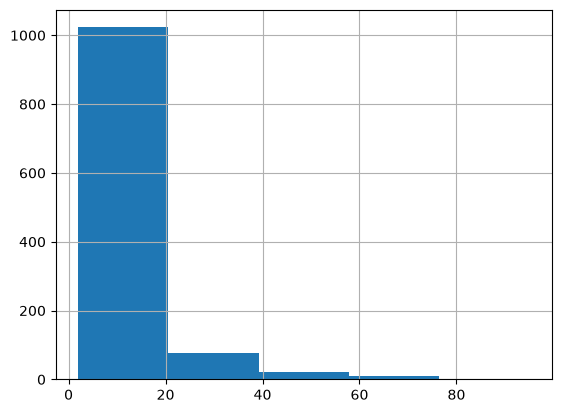

In [50]:
df['num_tokens_text'].hist(bins=5)

In [51]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'
longs_df = df[~short_idx]
shorts_df = df[short_idx]

In [52]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

# def standardize_df(datfram):
#     datfram['normalized_score'] = (
#         datfram['highest_score'] - datfram['highest_score'].mean()
#     )/datfram['highest_score'].std()

# standardize_df(df)
# standardize_df(shorts_df)
# standardize_df(longs_df)

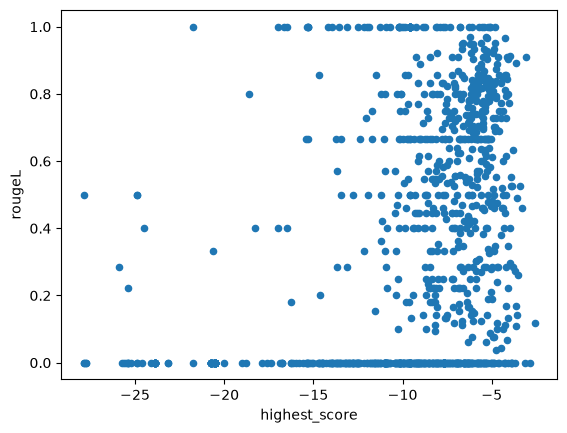

Pearson r: 0.4717
P-value: 0.0000


In [53]:
corr_analysis(df)

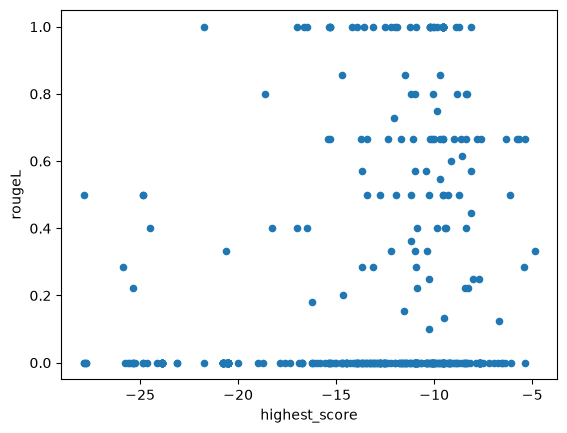

Pearson r: 0.3679
P-value: 0.0000


In [54]:
corr_analysis(shorts_df)

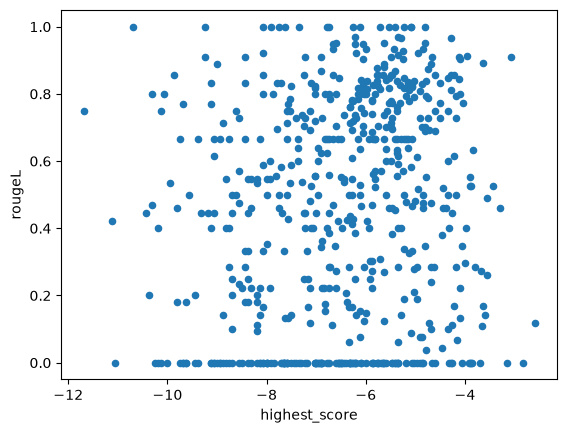

Pearson r: 0.1392
P-value: 0.0006


In [55]:
corr_analysis(longs_df)

<Axes: >

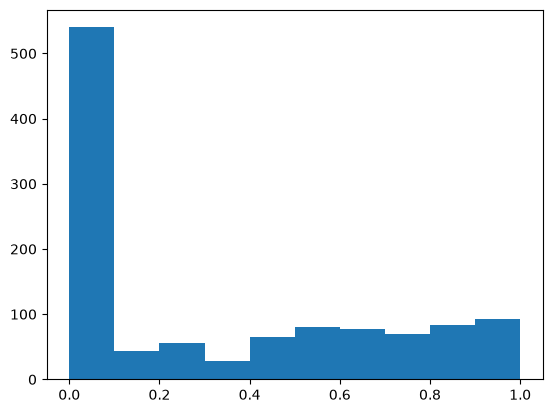

In [56]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

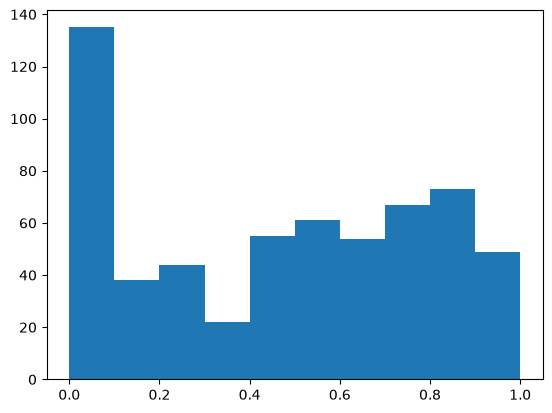

In [57]:
longs_df['rougeL'].hist(grid=False, bins=10)

<Axes: >

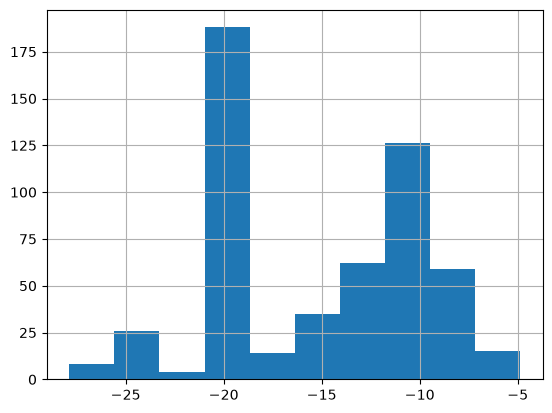

In [58]:
shorts_df['highest_score'].hist()

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["highest_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["highest_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, -df["highest_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["highest_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [60]:
pd.set_option('display.max_colwidth', None)

Best threshold: -2.8171
ROCAUC: 0.7337018862033624
Best F1: 0.7841
Precision at best F1: 0.6455
Recall at best F1: 0.9986



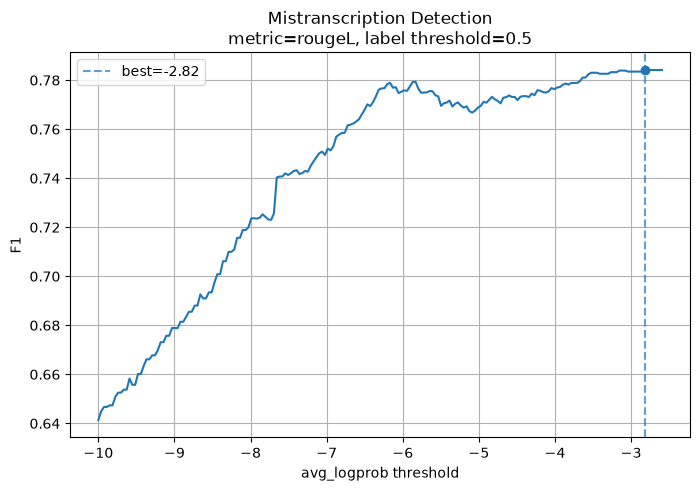

In [61]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -2.8171
ROCAUC: 0.5725977891156463
Best F1: 0.6577
Precision at best F1: 0.4908
Recall at best F1: 0.9966



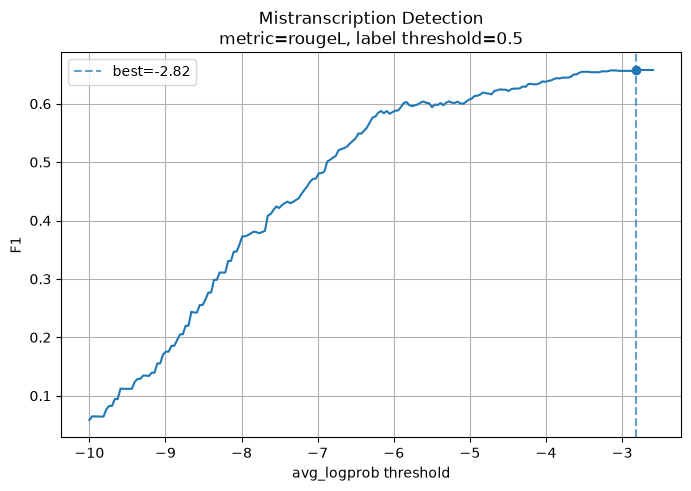

In [62]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -7.3948
ROCAUC: 0.793157090692302
Best F1: 0.7300
Precision at best F1: 0.6672
Recall at best F1: 0.8060



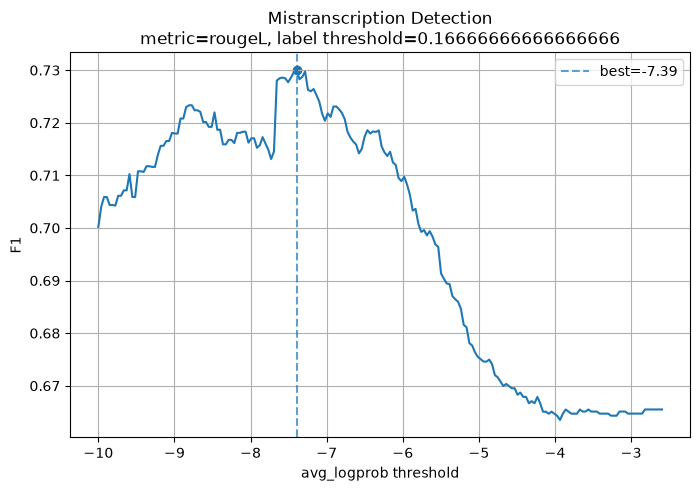

In [63]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: -2.8171
ROCAUC: 0.5556818181818182
Best F1: 0.4159
Precision at best F1: 0.2630
Recall at best F1: 0.9937



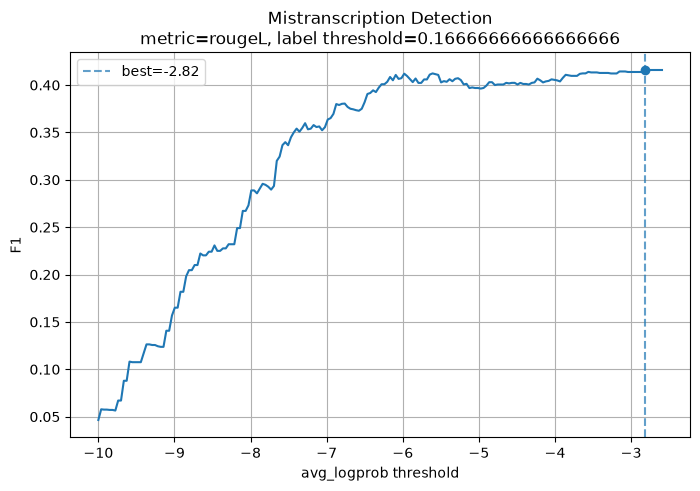

In [64]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# ml stuff

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df['y_true'] = errors_idx
df_val['y_true'] = df_val['rougeL'] < 0.5

FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
]

def train_and_eval_rf(FEATURES):
    TARGET = "y_true"
    
    # --------------------
    # Train RF
    # --------------------
    
    X_train = df[FEATURES]
    y_train = df[TARGET].astype(int)
    
    X_val = df_val[FEATURES]
    y_val = df_val[TARGET].astype(int)
    
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1,
    )
    
    rf.fit(X_train, y_train)
    
    # --------------------
    # Predictions
    # --------------------
    
    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs = rf.predict_proba(X_val)[:, 1]
    
    # --------------------
    # Overall AUROC
    # --------------------
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"Train AUROC: {train_auc:.4f}")
    print(f"Val   AUROC: {val_auc:.4f}")
    
    # --------------------
    # Short / Long subsets
    # --------------------
    
    train_shorts_idx = df["num_tokens_text"] <= 5
    val_shorts_idx = df_val["num_tokens_text"] <= 5
    
    def subset_auc(y, probs, mask):
        if y[mask].nunique() < 2:
            return float("nan")
        return roc_auc_score(y[mask], probs[mask])
    
    print("\nTRAIN")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_train, train_probs, train_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_train, train_probs, ~train_shorts_idx):.4f}"
    )
    
    print("\nVALIDATION")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_val, val_probs, val_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_val, val_probs, ~val_shorts_idx):.4f}"
    )


    def elbow_plot(
        y_true,
        scores,
        threshold_range=None,
        n_thresholds=200,
    ):
        """
        Finds the threshold maximizing F1.
    
        Parameters
        ----------
        y_true : array-like of bool/int
            Ground truth labels (1 = error).
    
        scores : array-like
            Probability or score where LARGER means MORE likely to be an error.
    
        threshold_range : (min, max) or None
            Threshold search range. Defaults to score min/max.
    
        Returns
        -------
        best_threshold, best_f1, best_precision, best_recall
        """
    
        y_true = np.asarray(y_true).astype(int)
        scores = np.asarray(scores)
    
        if threshold_range is None:
            tmin = scores.min()
            tmax = scores.max()
        else:
            tmin, tmax = threshold_range
    
        thresholds = np.linspace(tmin, tmax, n_thresholds)
    
        f1s = []
        precisions = []
        recalls = []
    
        for t in thresholds:
            pred = scores >= t
    
            precisions.append(
                precision_score(y_true, pred, zero_division=0)
            )
            recalls.append(
                recall_score(y_true, pred, zero_division=0)
            )
            f1s.append(
                f1_score(y_true, pred, zero_division=0)
            )
    
        f1s = np.array(f1s)
        precisions = np.array(precisions)
        recalls = np.array(recalls)
    
        best_idx = np.argmax(f1s)
    
        best_threshold = thresholds[best_idx]
        best_f1 = f1s[best_idx]
        best_precision = precisions[best_idx]
        best_recall = recalls[best_idx]
    
        plt.figure(figsize=(7,4))
        plt.plot(thresholds, f1s, label="F1")
        plt.plot(thresholds, precisions, label="Precision")
        plt.plot(thresholds, recalls, label="Recall")
    
        plt.axvline(
            best_threshold,
            linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}",
        )
    
        plt.xlabel("Threshold")
        plt.ylabel("Metric")
        plt.title("Threshold selection")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Best F1:        {best_f1:.4f}")
        print(f"Precision:      {best_precision:.4f}")
        print(f"Recall:         {best_recall:.4f}")

    val_probs = rf.predict_proba(X_val)[:, 1]
    elbow_plot(y_val[~val_shorts_idx], val_probs[~val_shorts_idx])

    return rf

In [ ]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
]

train_and_eval_rf(FEATURES)

In [ ]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob"
]

train_and_eval_rf(FEATURES)

In [ ]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
]
train_and_eval_rf(FEATURES)

In [ ]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
train_and_eval_rf(FEATURES)

In [ ]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
rf = train_and_eval_rf(FEATURES)